In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import proplot as pplt
import warnings
import matplotlib as mpl
import matplotlib.dates as dates
from datetime import date, timedelta
import warnings
warnings.filterwarnings('ignore')
#mpl.rcParams['xtick.labelsize'] = 12
#mpl.rcParams['ytick.labelsize'] = 12

In [2]:
# File paths
dir_topo = 'D:/yuanqi/new urania partition/camels_clim_nosnow.txt'
topo_path = 'D:/yuanqi/new_pdm/camels_attributes_v2.0/camels_attributes_v2.0/camels_topo.txt'
vege_path = 'D:/yuanqi/new_pdm/camels_attributes_v2.0/camels_attributes_v2.0/camels_vege.txt'
# Read and sort camels_info
camels_info = pd.read_csv(dir_topo, delimiter=';')
camels_info = camels_info.sort_values(by='aridity').reset_index(drop=True)
gauge_id = camels_info['gauge_id'].values.astype(np.int64)

# Read topo_info
topo_info = pd.read_csv(topo_path, delimiter=';')
vege_info = pd.read_csv(vege_path, delimiter=';')


# Merge camels_info with topo_info on gauge_id
camels_info = pd.merge(camels_info, topo_info, on='gauge_id', how='left')

# Merge the result with vege_info on gauge_id
camels_info = pd.merge(camels_info, vege_info, on='gauge_id', how='left')

In [3]:
camels_info.to_csv('D:/yuanqi/new urania partition/regime curve/camles_info.csv')

In [4]:
sdate = date(1987,1,1)
edate = date(2014,12,31)
ddate = pd.date_range(start=sdate, end=edate, freq='D')

In [6]:
def timeseries_coverter1(data_array, start_yr, ending_yr):
    
    from datetime import date, timedelta
    sdate = date(start_yr,1,1)
    edate = date(ending_yr, 12, 31)  
    data_ts = pd.DataFrame(data_array)
    data_ts.index = pd.date_range(start=sdate, end=edate, freq='D')
    ##
    monthly = np.squeeze(np.array(data_ts.resample('M').sum()))
    mean_monthly_data = np.reshape(monthly, (-1, 12)).mean(axis=0)
    return mean_monthly_data

regime

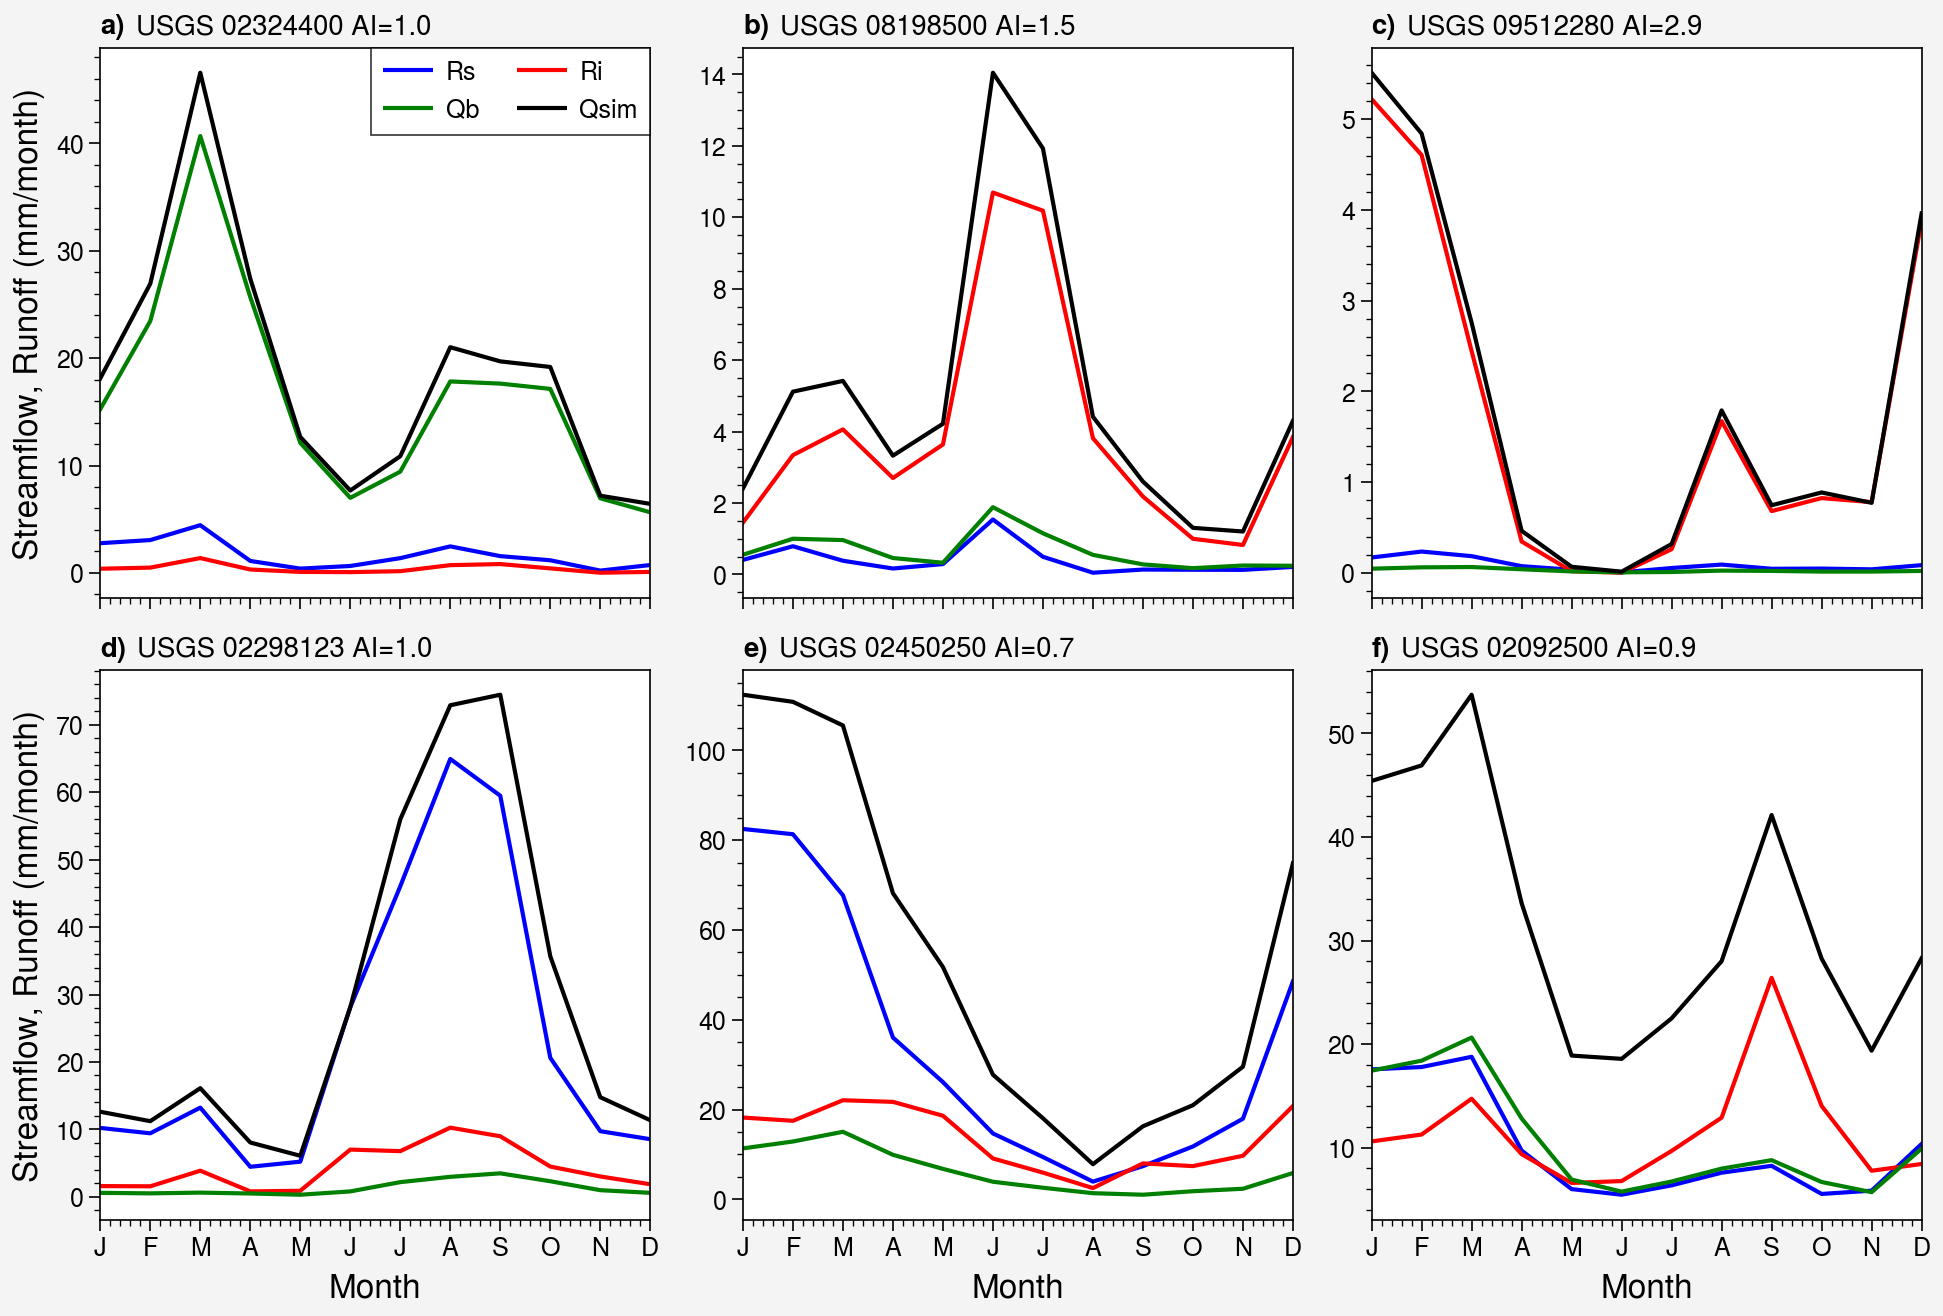

In [21]:
import pandas as pd
import numpy as np
import proplot as pplt

# Specify six station IDs to process
station_ids = ['02324400', '08198500', '09512280', '02298123', '02450250', '02092500']  # Replace with desired station IDs

# Create a 2x3 grid for the plots
fig, axs = pplt.subplots(nrows=2, ncols=3, refwidth='2.75in', refheight='2.75in', sharey=0, span=False)
SAVE_KWDS = {"bbox_inches": "tight", "dpi": 500, "facecolor": "w"}

for i, stationid in enumerate(station_ids):
    # Process each station ID
    stationid = float(stationid)
    camels_info['gauge_id'] = camels_info['gauge_id'].astype(float)
    aridity = camels_info[camels_info['gauge_id'] == stationid]['aridity'].iloc[0]
    aridity = round(aridity, 3)
    slope = camels_info[camels_info['gauge_id'] == stationid]['slope_mean_x'].iloc[0]
    slope = round(slope, 3)
    vege = camels_info[camels_info['gauge_id'] == stationid]['dom_land_cover'].iloc[0]

    stationid = "%08d" % stationid
    outd_file = pd.read_csv('D:/yuanqi/1106/sim/' + str(stationid) + '_AI_' + str(aridity) + '_simulated26.csv', index_col=0)

    # Prepare data
    outd = outd_file[730:]
    q = np.array(outd['Qsim'])
    rd = np.array(outd['rd'])
    ri = np.array(outd['ri'])
    rs = rd - ri
    qb = np.array(outd['qb'])
    qd = np.array(outd['qd'])

    regime_q = timeseries_coverter1(q, 1987, 2014)
    regime_rd = timeseries_coverter1(rd, 1987, 2014)
    regime_rs = timeseries_coverter1(rs, 1987, 2014)
    regime_ri = timeseries_coverter1(ri, 1987, 2014)
    regime_qb = timeseries_coverter1(qb, 1987, 2014)

    regime = pd.DataFrame()
    regime['rs'] = regime_rs
    regime['ri'] = regime_ri
    regime['q'] = regime_q
    regime['qb'] = regime_qb

    regime.index = np.arange(0, 12, 1)
    regime.index = regime.index.astype(float)

    # Select the subplot
    ax = axs[i]

    # Plot the data on the subplot
    plot = regime.plot(y='rs', c='blue', label='Rs', linestyle='-', ax=ax, legend=False)
    regime.plot(y='ri', c='red', label='Ri', linestyle='-', ax=ax, legend=False)
    regime.plot(y='qb', c='green', label='Qb', linestyle='-', ax=ax, legend=False)
    regime.plot(y='q', c='black', label='Qsim', linestyle='-', ax=ax, legend=False)

    # Add legend only for the first subplot
    if i == 0:
        ax.legend(loc='upper right', ncol=2)#, frame=False)

    # Format the subplot
    ax.format(abc='a)',
        ylabel='Streamflow, Runoff (mm/month)' if i % 3 == 0 else '',
        xlabel='Month' if i >= 3 else '',
        title='USGS ' + str(stationid) + ' AI=' + str(round(aridity, 1)),# +
        #' s=' + str(round(slope, 1)) + ' ' + vege,
        titleloc='l', labelsize=12, grid=False
    )
    major_xticks = np.arange(0, 12, 1)
    ax.set_xticks(major_xticks)
    ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])


# Save the final figure
fig.save('D:/yuanqi/new urania partition/2x3_catchments_plot.png', **SAVE_KWDS)
